# Heart Disease Severity & Diagnosis Prediction
## Week 1 - ML Pipeline
**Sardar Ahmed** -
**Dataset:** UCI Heart Disease Dataset (920 Patient Records, 16 Features)  

## 1. Environment & Library Setup


In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any, Optional

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from xgboost import XGBClassifier

# IGNORE - these settings are for styling of the eda that i got from documentation
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.autolayout": True, "font.size": 11})

## 2. In-Depth Exploratory Data Analysis (EDA)
In this section, we inspect the raw data structure, identify missingness mechanisms, detect biological anomalies (e.g. 0 cholesterol/blood pressure), and explore clinical correlations.



In [4]:
df_raw = pd.read_csv("heart_disease_uci.csv")
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset Shape: 920 rows, 16 columns


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
# Summary of missing values across all features
missing_stats = df_raw.isnull().sum()
missing_percent = (missing_stats / len(df_raw)) * 100
missing_summary = pd.DataFrame({"Missing Count": missing_stats, "Missing (%)": missing_percent})
missing_summary[missing_summary["Missing Count"] > 0].sort_values(by="Missing (%)", ascending=False)

,Missing Count,Missing (%)
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
exang,55,5.978261
thalch,55,5.978261
chol,30,3.260870
restecg,2,0.217391


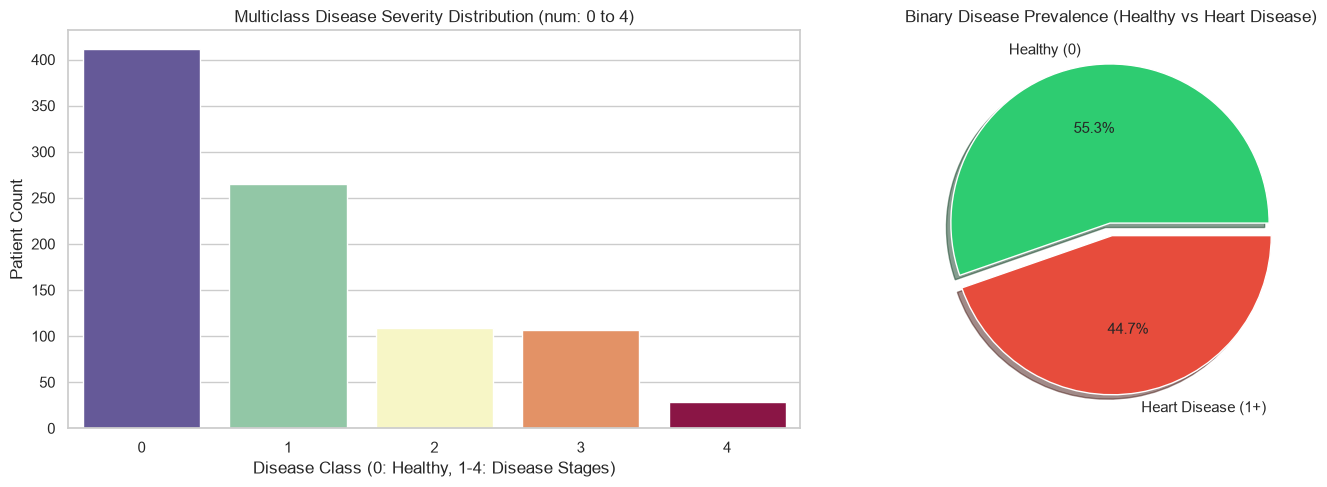

In [6]:
# Target Distribution: 5-Class Multiclass vs Binary Diagnosis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Multiclass Distribution
sns.countplot(data=df_raw, x="num", hue="num", palette="Spectral_r", ax=axes[0], legend=False)
axes[0].set_title("Multiclass Disease Severity Distribution (num: 0 to 4)")
axes[0].set_xlabel("Disease Class (0: Healthy, 1-4: Disease Stages)")
axes[0].set_ylabel("Patient Count")

# Binary Distribution
df_raw["disease_present"] = (df_raw["num"] > 0).astype(int)
df_raw["disease_present"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", labels=["Healthy (0)", "Heart Disease (1+)"],
    colors=["#2ecc71", "#e74c3c"], ax=axes[1], explode=(0.04, 0.04), shadow=True
)
axes[1].set_title("Binary Disease Prevalence (Healthy vs Heart Disease)")
axes[1].set_ylabel("")

plt.show()

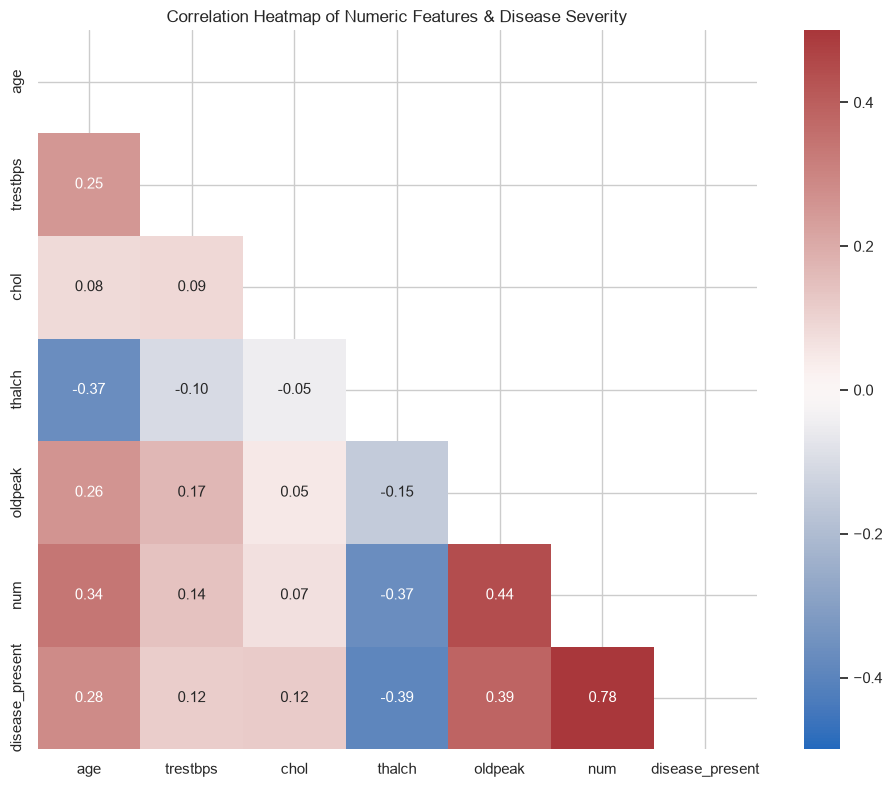

In [7]:
# Correlation Heatmap of Clinical Metrics
plt.figure(figsize=(10, 8))
clean_for_corr = df_raw.copy()
clean_for_corr["trestbps"] = clean_for_corr["trestbps"].replace(0, np.nan)
clean_for_corr["chol"] = clean_for_corr["chol"].replace(0, np.nan)

numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "num", "disease_present"]
corr_mat = clean_for_corr[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-0.5, vmax=0.5, square=True)
plt.title("Correlation Heatmap of Numeric Features & Disease Severity")
plt.show()

## 3. Object-Oriented Machine Learning Pipeline Execution

Executing the pipeline by importing it from the .py file


In [8]:
from heart_disease_prediction import HeartDiseasePipeline

# Execute full multiclass pipeline
pipeline = HeartDiseasePipeline(
    data_path="heart_disease_uci.csv",
    output_model_path="xgboost_model.pkl"
)
pipeline.run()


############################################################
   STARTING HEART DISEASE MACHINE LEARNING PIPELINE
############################################################

[DataLoader] Successfully loaded dataset with shape: (920, 16)
[DataLoader] Dropped non-predictive/high-missingness columns: ['id', 'slope', 'ca', 'thal']
[DataLoader] Features shape: (920, 11), Target distribution:
{0: 411, 1: 265, 2: 109, 3: 107, 4: 28}
[Pipeline] Stratified Split -> Train: 736 samples, Test: 184 samples

--- Training Random Forest Baseline ---

       Evaluation Results: Random Forest Baseline
Accuracy:            57.61%
Macro F1-Score:      0.4454
Weighted F1-Score:   0.6035

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.88      0.40      0.55        53
           2       0.26      0.32      0.29        22
           3       0.30      0.62      0.41        21
           4       0.12     

## 4. Binary Classification Benchmark (Healthy vs Heart Disease)
In cardiology, binary classification (presence vs. absence of coronary artery disease, narrowing > 50%) is the standard clinical benchmark. Below we train and evaluate our pipeline on binary diagnosis.

In [9]:
from heart_disease_prediction import DataLoader, DataPreprocessor, ModelTrainer, ModelEvaluator

# 1. Load Data
loader = DataLoader("heart_disease_uci.csv")
X_raw, y_multi = loader.load_and_clean()
y_binary = (y_multi > 0).astype(int)

# 2. Stratified Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 3. Preprocessor
num_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]
cat_features = ["sex", "dataset", "cp", "fbs", "restecg", "exang"]
preprocessor = DataPreprocessor(num_features, cat_features).build_transformer()

# 4. Train Model
trainer = ModelTrainer(preprocessor=preprocessor, random_state=42)
bin_xgb = trainer.create_pipeline(
    XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric="logloss", n_jobs=1)
)
bin_xgb.fit(X_tr, y_tr)

# 5. Evaluate
evaluator = ModelEvaluator()
results = evaluator.evaluate(bin_xgb, X_te, y_te, model_name="Binary XGBoost Classifier")

[DataLoader] Successfully loaded dataset with shape: (920, 16)
[DataLoader] Dropped non-predictive/high-missingness columns: ['id', 'slope', 'ca', 'thal']
[DataLoader] Features shape: (920, 11), Target distribution:
{0: 411, 1: 265, 2: 109, 3: 107, 4: 28}

       Evaluation Results: Binary XGBoost Classifier
Accuracy:            82.07%
Macro F1-Score:      0.8183
Weighted F1-Score:   0.8205

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        82
           1       0.83      0.84      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184

